# Training: Full-Day Episodes

Trains offline RL policies on the full-day-based dataset, where each episode is one cultivation day and
can contain several irrigations. The cumulative state variables are not reset between irrigations, so the
policy has to schedule multiple watering events across the day.

Dataset: `../data/episFormula/7.3 correct drain`. Observations are `doy`, `abstime`, `time`, `temp`,
`humi`, `light`, `drain`; the action is `timeToIrri`. Compared to the interval-based notebook this setup
uses a larger batch size (256), `gamma=0.95`, gradient clipping and a standardized reward scaler.

Steps:
1. `read_Episodes` loads each episode CSV and stops at the first `terminal == 1` row.
2. Build the `MDPDataset`, configure IQL, BCQ, CQL and PLAS, and train the selected model(s) for 500,000
   steps, saving the final policy under `logs/<experiment>/models`.
3. Load the training logs and plot the `diff_eval` metric to inspect convergence.

In [8]:
import os
import csv

#reads all the episodes in a particular folder and returns them in a array consisting of arrays with tuples
#stops reading each episode when terminal == 1 (includes the first terminal=1 row)
def read_Episodes(baseFolder):
    episodes = []
    headers = None
    
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            file_headers = next(reader)  # Read header row
            
            # Store headers from first file
            if headers is None:
                headers = file_headers
                # Find terminal column index
                terminal_index = headers.index('terminal')
            
            for row in reader:
                observation = [float(value) for value in row]
                episode.append(observation)
                
                # Stop reading after first terminal == 1
                if int(observation[terminal_index]) == 1:
                    break
                    
            episodes.append(episode)        
    
    return episodes, headers

In [9]:
#TODO: Testen mit verschiedenen großen Datensätzen

## Build dataset and train

Maps the observation, action, reward and terminal columns into an `MDPDataset`, defines the algorithm
configurations and hyperparameters, trains the selected model(s) with shared evaluators, and saves the
final policy. `dataset_fractions` allows training on a subset of episodes to study the effect of dataset
size.

In [18]:
import d3rlpy
import numpy as np
import os
import random
from d3rlpy.optimizers import AdamFactory

EPIfolder = "../data/episFormula/7.3 correct drain"
EPIfolder2 = "../data/episFormula/4 cumsum measured"

epis, headers = read_Episodes(EPIfolder) #+ read_Episodes(EPIfolder2)

# Get column indices based on headers
obs_columns = ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain']
action_column = 'timeToIrri'
reward_column = 'reward'
terminal_column = 'terminal'

# Create index mappings
obs_indices = [headers.index(col) for col in obs_columns]
action_index = headers.index(action_column)
reward_index = headers.index(reward_column)
terminal_index = headers.index(terminal_column)

print(f"Headers: {headers}")
print(f"Observation columns: {obs_columns} -> indices: {obs_indices}")
print(f"Action column: {action_column} -> index: {action_index}")
print(f"Reward column: {reward_column} -> index: {reward_index}")
print(f"Terminal column: {terminal_column} -> index: {terminal_index}")
print(f"Total episodes: {len(epis)}")

# === FUNKTION ZUM ERSTELLEN VON DATASETS MIT VERSCHIEDENEN GRÖSSEN ===
def create_dataset_from_episodes(episodes, fraction=1.0):
    """Erstellt ein Dataset aus einem Bruchteil der Episoden."""
    random.seed(42)  # Für Reproduzierbarkeit
    
    # Episoden zufällig auswählen
    n_episodes = int(len(episodes) * fraction)
    selected_indices = random.sample(range(len(episodes)), n_episodes)
    selected_episodes = [episodes[i] for i in sorted(selected_indices)]
    
    observations = []
    actions = []
    rewards = []
    terminals = []
    
    for epi in selected_episodes:
        for observation in epi:
            observations.append([observation[i] for i in obs_indices])
            actions.append([observation[action_index]])
            rewards.append(observation[reward_index])
            terminals.append(int(observation[terminal_index]))
    
    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)
    terminals = np.array(terminals)
    
    dataset = d3rlpy.dataset.MDPDataset(
        action_space=d3rlpy.constants.ActionSpace.CONTINUOUS,
        observations=observations,
        actions=actions,
        rewards=rewards,
        terminals=terminals,
    )
    
    return dataset, observations, actions, rewards, terminals

# === OPTIMIERER MIT GRADIENT CLIPPING ===
optim_factory = AdamFactory(clip_grad_norm=1.0)

# === SCALER (werden für alle Experimente verwendet) ===
action_scaler = d3rlpy.preprocessing.MinMaxActionScaler()
observation_scaler = d3rlpy.preprocessing.MinMaxObservationScaler()
reward_scaler = d3rlpy.preprocessing.StandardRewardScaler()

# extract folder name from EPIfolder path for logging
folder_name = os.path.basename(EPIfolder)

# === EXPERIMENTE MIT VERSCHIEDENEN DATENSATZGRÖSSEN ===
dataset_fractions = [1]

for fraction in dataset_fractions:
    print(f"\n{'#'*80}")
    print(f"# EXPERIMENT: {int(fraction*100)}% des Datensatzes")
    print(f"{'#'*80}")
    
    # Dataset erstellen
    dataset, obs, acts, rews, terms = create_dataset_from_episodes(epis, fraction)
    
    print(f"\n=== Dataset Statistiken ({int(fraction*100)}%) ===")
    print(f"Observations shape: {obs.shape}")
    print(f"Number of episodes: {len(dataset.episodes)}")
    print(f"Rewards - Min: {rews.min():.2f}, Max: {rews.max():.2f}, Mean: {rews.mean():.2f}, Std: {rews.std():.2f}")
    print(f"Actions - Min: {acts.min():.2f}, Max: {acts.max():.2f}")
    
    # Test-Episoden auswählen
    random.seed(42)
    test_episodes = []
    n_test = min(500, len(dataset.episodes))
    for i in range(n_test):
        test_episodes.append(dataset.episodes[random.randint(0, len(dataset.episodes)-1)])
    
    # Logger für dieses Experiment
    experiment_name = f"{folder_name}_{int(fraction*100)}pct_final"
    logger_adapter = d3rlpy.logging.CombineAdapterFactory([
       d3rlpy.logging.FileAdapterFactory(root_dir=f"logs/{experiment_name}/d3rlpy_logs")
    ])
    
    # === MODEL-KONFIGURATIONEN ===
    
    # IQL - Bestes Modell aus vorherigem Experiment
    IQL_model = d3rlpy.algos.IQLConfig(
        action_scaler=action_scaler,
        observation_scaler=observation_scaler,
        reward_scaler=reward_scaler,
        batch_size=256,
        gamma=0.95,
        tau=0.001,
        actor_learning_rate=3e-4,
        critic_learning_rate=3e-4,
        actor_optim_factory=optim_factory,
        critic_optim_factory=optim_factory,
        n_critics=2,
        expectile=0.7,
        weight_temp=3.0,
        max_weight=100.0,
    ).create(device='cuda:0')
    
    # BCQ
    BCQ_model = d3rlpy.algos.BCQConfig(
        action_scaler=action_scaler,
        observation_scaler=observation_scaler,
        reward_scaler=reward_scaler,
        batch_size=256,
        gamma=0.95,
        tau=0.001,
        actor_learning_rate=1e-4,
        critic_learning_rate=1e-4,
        imitator_learning_rate=1e-4,
        actor_optim_factory=optim_factory,
        critic_optim_factory=optim_factory,
        imitator_optim_factory=optim_factory,
        n_critics=2,
        lam=0.75,
        n_action_samples=100,
        action_flexibility=0.05,
        beta=0.5,
    ).create(device='cuda:0')
    
    # CQL mit reduziertem conservative_weight
    CQL_model = d3rlpy.algos.CQLConfig(
        action_scaler=action_scaler,
        observation_scaler=observation_scaler,
        reward_scaler=reward_scaler,
        batch_size=256,
        gamma=0.95,
        tau=0.001,
        actor_learning_rate=1e-4,
        critic_learning_rate=3e-4,
        temp_learning_rate=1e-4,
        alpha_learning_rate=1e-4,
        actor_optim_factory=optim_factory,
        critic_optim_factory=optim_factory,
        temp_optim_factory=optim_factory,
        alpha_optim_factory=optim_factory,
        n_critics=2,
        initial_alpha=1.0,
        conservative_weight=1.0,  # Reduziert von 5.0!
        alpha_threshold=10.0,
        n_action_samples=10,
    ).create(device='cuda:0')
    
    # PLAS mit längerer Warmup-Phase
    PLAS_model = d3rlpy.algos.PLASConfig(
        action_scaler=action_scaler,
        observation_scaler=observation_scaler,
        reward_scaler=reward_scaler,
        batch_size=256,
        gamma=0.95,
        tau=0.001,
        actor_learning_rate=1e-4,
        critic_learning_rate=3e-4,  # Reduziert von 1e-3
        imitator_learning_rate=1e-4,
        actor_optim_factory=optim_factory,
        critic_optim_factory=optim_factory,
        imitator_optim_factory=optim_factory,
        n_critics=2,
        lam=0.75,
        warmup_steps=500000,  # Erhöht von 50000
        beta=0.5,
    ).create(device='cuda:0')
    
    # Modelle trainieren
    Models = [PLAS_model]
    
    for Model in Models:
        print(f"\n{'='*60}")
        print(f"Training: {Model.__class__.__name__} mit {int(fraction*100)}% Daten")
        print(f"{'='*60}")
        
        result = Model.fit(
            dataset,
            n_steps=500000,
            n_steps_per_epoch=2500,
            evaluators={
                'td_error': d3rlpy.metrics.TDErrorEvaluator(test_episodes),
                'value_scale': d3rlpy.metrics.AverageValueEstimationEvaluator(test_episodes),
                'discounted_advantage': d3rlpy.metrics.DiscountedSumOfAdvantageEvaluator(test_episodes),
                'initial_state': d3rlpy.metrics.InitialStateValueEstimationEvaluator(test_episodes),
                'diff_eval': d3rlpy.metrics.ContinuousActionDiffEvaluator(test_episodes)
            },
            logger_adapter=logger_adapter,
        )
        
        # Modell speichern
        model_save_path = f"logs/{experiment_name}/models/{Model.__class__.__name__}_final.d3"
        os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
        Model.save(model_save_path)
        print(f"Modell gespeichert: {model_save_path}")

print(f"\n{'#'*80}")
print("# ALLE EXPERIMENTE ABGESCHLOSSEN!")
print(f"{'#'*80}")

Headers: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal', 'idealIrri', 'evoCumsum']
Observation columns: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain'] -> indices: [0, 1, 2, 3, 4, 5, 6]
Action column: timeToIrri -> index: 7
Reward column: reward -> index: 8
Terminal column: terminal -> index: 9
Total episodes: 11424

################################################################################
# EXPERIMENT: 100% des Datensatzes
################################################################################
2026-02-15 20:30.25 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2026-02-15 20:30.25 [info     ] Action size has been automatically determined. action_size=1

=== Dataset Statistiken (100%) ===
Observat

Epoch 1/200: 100%|██████████| 2500/2500 [00:32<00:00, 75.83it/s, vae_loss=0.0406]


2026-02-15 20:31.31 [info     ] PLAS_20260215203046: epoch=1 step=2500 epoch=1 metrics={'time_sample_batch': 0.004707261085510254, 'time_algorithm_update': 0.007960986137390137, 'vae_loss': 0.04054519567936659, 'time_step': 0.01293047685623169, 'td_error': 1.0056074144956495, 'value_scale': -0.02403240602499258, 'discounted_advantage': 0.002066714315361612, 'initial_state': 0.006353190168738365, 'diff_eval': 17895.26238021448} step=2500
2026-02-15 20:31.31 [info     ] Model parameters are saved to logs/7.3 correct drain_100pct_final/d3rlpy_logs\PLAS_20260215203046\model_2500.d3


Epoch 2/200: 100%|██████████| 2500/2500 [00:33<00:00, 74.15it/s, vae_loss=0.027] 


2026-02-15 20:32.16 [info     ] PLAS_20260215203046: epoch=2 step=5000 epoch=2 metrics={'time_sample_batch': 0.004863124370574951, 'time_algorithm_update': 0.008109724903106689, 'vae_loss': 0.02697222933769226, 'time_step': 0.013228057193756103, 'td_error': 1.0058074677933226, 'value_scale': -0.02424491093837751, 'discounted_advantage': 0.00460546799797574, 'initial_state': 0.0056278277188539505, 'diff_eval': 16641.931981676702} step=5000
2026-02-15 20:32.16 [info     ] Model parameters are saved to logs/7.3 correct drain_100pct_final/d3rlpy_logs\PLAS_20260215203046\model_5000.d3


...

2026-02-15 23:03.32 [info     ] PLAS_20260215203046: epoch=198 step=495000 epoch=198 metrics={'time_sample_batch': 0.004776257228851318, 'time_algorithm_update': 0.007975956249237061, 'vae_loss': 0.00920782824633643, 'time_step': 0.012999166965484619, 'td_error': 1.0052059397819262, 'value_scale': -0.023872556486012487, 'discounted_advantage': -0.0005912365248012568, 'initial_state': 0.006427922286093235, 'diff_eval': 6315.8297554036035} step=495000
2026-02-15 23:03.32 [info     ] Model parameters are saved to logs/7.3 correct drain_100pct_final/d3rlpy_logs\PLAS_20260215203046\model_495000.d3


Epoch 199/200: 100%|██████████| 2500/2500 [00:32<00:00, 76.97it/s, vae_loss=0.00912]


2026-02-15 23:04.16 [info     ] PLAS_20260215203046: epoch=199 step=497500 epoch=199 metrics={'time_sample_batch': 0.0046853899002075195, 'time_algorithm_update': 0.007818797492980957, 'vae_loss': 0.009110624504555017, 'time_step': 0.012746639251708984, 'td_error': 1.0049933517873237, 'value_scale': -0.023829984108987023, 'discounted_advantage': -0.000940996633201981, 'initial_state': 0.006490127649158239, 'diff_eval': 6133.619065281672} step=497500
2026-02-15 23:04.16 [info     ] Model parameters are saved to logs/7.3 correct drain_100pct_final/d3rlpy_logs\PLAS_20260215203046\model_497500.d3


Epoch 200/200: 100%|██████████| 2500/2500 [00:32<00:00, 76.09it/s, vae_loss=0.00921]


2026-02-15 23:05.00 [info     ] PLAS_20260215203046: epoch=200 step=500000 epoch=200 metrics={'time_sample_batch': 0.004773386478424072, 'time_algorithm_update': 0.00785371618270874, 'vae_loss': 0.009208702514786274, 'time_step': 0.012879093647003174, 'td_error': 1.0051670275166058, 'value_scale': -0.024061721997959185, 'discounted_advantage': 0.002296939401881362, 'initial_state': 0.005318020936101675, 'diff_eval': 6079.106564595687} step=500000
2026-02-15 23:05.00 [info     ] Model parameters are saved to logs/7.3 correct drain_100pct_final/d3rlpy_logs\PLAS_20260215203046\model_500000.d3
Modell gespeichert: logs/7.3 correct drain_100pct_final/models/PLAS_final.d3

################################################################################
# ALLE EXPERIMENTE ABGESCHLOSSEN!
################################################################################


## Training analysis

Loads the written log files and plots the recorded metrics (for example `diff_eval`) over the training
epochs to check convergence and compare runs.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Lade Log-Dateien für Analyse
log_base = f"logs/{experiment_name}/d3rlpy_logs"

# Finde die Log-Ordner
if os.path.exists(log_base):
    log_folders = [f for f in os.listdir(log_base) if os.path.isdir(os.path.join(log_base, f))]
    print(f"Gefundene Log-Ordner: {log_folders}")
else:
    print(f"Log-Ordner nicht gefunden: {log_base}")
    log_folders = []

Gefundene Log-Ordner: ['BCQ_20260215032348', 'IQL_20260214233207', 'PLAS_20260215154500', 'PLAS_20260215203046']


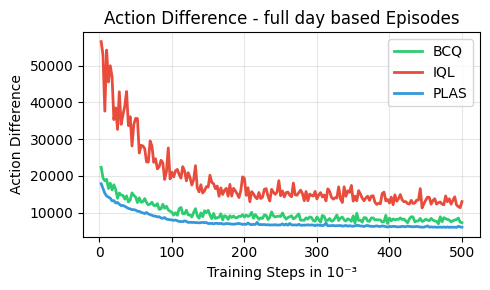

In [21]:
# Visualisierung der Trainings-Ergebnisse
if log_folders:
    fig, axes = plt.subplots(1, 1, figsize=(5, 3))
    colors = {'BCQ': '#2ecc71', 'PLAS': '#3498db', 'IQL': '#e74c3c', 'CQL': "#faf603"}
    
    for folder in log_folders:
        model_name = folder.split('_')[0]
        color = colors.get(model_name, '#999999')
        
        # diff_eval laden
        diff_path = os.path.join(log_base, folder, 'diff_eval.csv')
        if os.path.exists(diff_path):
            df = pd.read_csv(diff_path, header=None, names=['epoch', 'step', 'value'])
            axes.plot(df['step']/1000, df['value'], label=model_name, color=color, linewidth=2)
    
    axes.set_xlabel('Training Steps in 10⁻³')
    axes.set_title('Action Difference - full day based Episodes')
    axes.set_ylabel('Action Difference')
    axes.legend()
    axes.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Keine Log-Daten gefunden. Führe zuerst das Training aus.")